In [10]:
# Install required packages (run once)
!pip -q install simpy networkx scikit-learn
!pip -q uninstall -y mesa
!pip -q install mesa==2.2.4

In [11]:
from mesa import Agent, Model
from mesa.time import RandomActivation
from mesa.space import NetworkGrid
import networkx as nx


class RouterAgent(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        self.load = 0

    def step(self):
        # Simulate random load changes
        self.load = max(0, min(100, self.load + self.random.randint(-10, 10)))

        if self.load > 80:
            print(f"Router {self.unique_id} overloaded! Rerouting traffic...")

In [21]:
class NetworkModel(Model):
    def __init__(self, N, seed=None):
        super().__init__(seed=seed) # Pass the seed to the parent Model
        self.num_agents = N
        self.schedule = RandomActivation(self)

        G = nx.generators.connected_watts_strogatz_graph(
            n=N,
            k=3,
            p=0.5,
            seed=seed if seed is not None else 42 # Use the provided seed for NetworkX if available
        )

        self.grid = NetworkGrid(G)

        for i in range(self.num_agents):
            a = RouterAgent(i, self)
            self.schedule.add(a)
            self.grid.place_agent(a, i)

    def step(self):
        self.schedule.step()

In [22]:
model = NetworkModel(5) # Instantiate the model without the 'seed' keyword argument

for i in range(10):
    print(f"--- Step {i+1} ---")
    model.step()

--- Step 1 ---
--- Step 2 ---
--- Step 3 ---
--- Step 4 ---
--- Step 5 ---
--- Step 6 ---
--- Step 7 ---
--- Step 8 ---
--- Step 9 ---
--- Step 10 ---


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [24]:
# Generate synthetic traffic data
time = np.arange(0, 100, 1)
traffic = 50 + 10 * np.sin(time / 5) + np.random.normal(0, 2, len(time))

In [25]:
# Prepare dataset
data = pd.DataFrame({
    'time': time,
    'traffic': traffic
})

data['lag_1'] = data['traffic'].shift(1)
data = data.dropna()

X = data[['lag_1']]
y = data['traffic']

In [26]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
# Predictions
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")

Mean Squared Error: 9.192


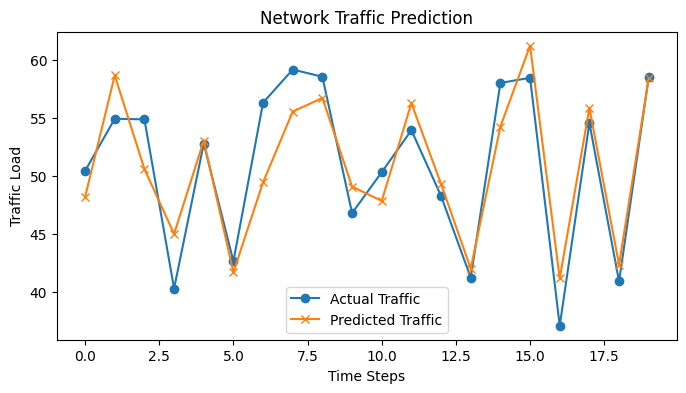

In [29]:
# Visualization
plt.figure(figsize=(8, 4))

plt.plot(
    y_test.values,
    label="Actual Traffic",
    marker="o"
)

plt.plot(
    y_pred,
    label="Predicted Traffic",
    marker="x"
)

plt.title("Network Traffic Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Traffic Load")
plt.legend()

plt.show()